# Optimization in PyTorch - Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
%pip install -q torch matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install datasets -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset

sst2 = load_dataset("SetFit/sst2")

data_train = sst2["train"]
data_val = sst2["validation"]

Repo card metadata block was not found. Setting CardData to empty.


In [4]:
import re


def clean_text(text: str) -> str:
    # lowercase letters only
    text = text.lower()

    # replace hyphens with space
    text = text.replace("-", " ")

    # keep letters,numbers, spaces, and basic punctuations
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)

    # collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# apply cleaning
data_train = data_train.map(lambda x: {"clean_text": clean_text(x["text"])})
data_val = data_val.map(lambda x: {"clean_text": clean_text(x["text"])})

In [5]:
import random
from collections import Counter

random.seed(42)

print(f"size of training set: {len(data_train)}")
print(f"size of validation set: {len(data_val)}\n")

for i in range(5):
    r = random.randint(0, len(data_train))
    print(f"{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ")

train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standard practice.


In [6]:
def tokenize(text):
    """Helper function to split the text into words/tokens"""
    return text.split()


def build_vocabulary(data, top_k=10000):
    """Build a vocabulary from the training data."""
    token_counter = Counter()
    for text in data["clean_text"]:
        tokens = tokenize(text)
        token_counter.update(tokens)
    most_common = token_counter.most_common(top_k)
    vocab = {word: i for i, (word, _) in enumerate(most_common)}
    return vocab


def convert_text_to_vec(text, vocab):
    """Convert text into a vector of token counts."""
    tokens = tokenize(text)
    vec = np.zeros(len(vocab), dtype=int)
    for token in tokens:
        if token in vocab:
            vec[vocab[token]] += 1
    return vec


def dataset_to_vec(data, vocab):
    """Convert the dataset into a vector of token counts."""
    vectors = []
    for text in data["clean_text"]:
        vec = convert_text_to_vec(text, vocab)
        vectors.append(vec)
    return np.array(vectors)

In [7]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f"Vocabulary size: {len(vocab)}")

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f"Vectorized training data shape: {train_vectors.shape}")

# one example vector
example = train_vectors[0]
print(f"\nExample vector: {example}")
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)

for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")

print(f"Example tokens : {tokenize(data_train['clean_text'][0])}")

print(f"Length of tokens: {len(tokenize(data_train['clean_text'][0]))}")
print(f"Length of non-zero entries: {len(indices[0])}")

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [8]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val = np.array(data_val["label"], dtype=np.float32)

### **Part 1 - Implement SGD for Logistic Regression in PyTorch (70 points)**

#### **Task 1.1 - Binary vs. Softmax Formulation and Numerical Stability of Cross-Entropy Loss (10 points)**



In this task, you will explore two ways to formulate the loss function for a classification problem and understand why numerical stability is important.

**a. Binary formulation**

   In the binary formulation, the model has:

   * a single output
   * sigmoid activation
   * binary cross-entropy loss

   This produces a probability: P(y=1|x)
   
   A prediction is then obtained using a threshold:
   * predict class 1 if p>0.5
   * otherwise predict class 0

   For binary logistic regression, the standard loss function is the **binary cross-entropy loss**:

   $L= -\frac{1}{N}\sum_{i=1}^N[y_ilog(\hat{y_i})+(1-y_i)log(1-\hat{y_i})]$

   where $\hat{y_i}$ is the predicted probability after applying sigmoid.

   Since this loss contains both: $log(\hat{y})$ and $log(1-\hat{y})$ , numerical problems may appear if $\hat{y_i}$ becomes extremely close to 0 or 1.

   A stable implementation should therefore clamp the predicted probabilities:
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```

**Note:** the threshold 0.5 is used only to convert probabilities into class predictions for evaluation.
It must not be used inside the loss function.

**b. Softmax formulation**

  Now, we will reformulate the same problem as a 2-class classification problem using softmax (This formulation is more general and can also be used for more than 2 classes).
  
  **Step 1 - Convert labels to one-hot encoding**
  
  In our dataset the labels are either 1 or 0 (i.e positive or negetive). To use softmax will require us to convert the labels into a one-hot representation:
  * class 0 ---> [1,0]
  * class 1 ---> [0,1]

  Now our model will output 2 outputs instead of 1 and we will require to apply softmax to get the probability of class 0 vs. class 1.

  **Step 2 - Implementing softmax and log-loss**
  
   This can be implemented in two ways:

  1. **Naive version:**
  
     Given logits z = [$z_1,z_2,...,z_k$]

     softmax($z_i$) = $\frac{\exp(z_i)}{\sum_j\exp(z_j)}$


  2. **Stable version:**

     softmax($z_i$) = $\frac{\exp(z_i-max(z))}{\sum_j\exp(z_j-max(z))}$

   Than the cross entropy loss for the true class y is :

   **L = -log(softmax($z_y$))**

   or equivalently, for one-hot labels:
   
   **$L= -\sum_{c=1}^Ky_clog(\hat{y_c})$**

**Task**

A. Conceptual questions

For both the binary and softmax formulations, explain:

* Why do we need numerical stability? Where can the naive implementation fail?
* Why does the stability transformation not change the final softmax probabilities?
* Why does this transformation improve numerical stability?

Answers:
* We need numerical stability because the naive implementations involve operations that can produce undefined or infinite values for extreme inputs. In the **binary formulation**, if the predicted probability ŷ reaches exactly 0 or 1, we compute log(0) = −∞, which produces NaN gradients and breaks training. In the **softmax formulation**, when logits are very large, exp(z_i) overflows to infinity; when all logits are very negative, every exp(z_i) underflows to zero, making the denominator zero and the division undefined.
* The stability transformation does not change the final softmax probabilities because subtracting the same constant c = max(z) from every logit factors out identically in numerator and denominator: exp(z_i − c) / Σ_j exp(z_j − c) = exp(z_i)·exp(−c) / [Σ_j exp(z_j)·exp(−c)] = exp(z_i) / Σ_j exp(z_j). The common factor exp(−c) cancels completely, so the output probabilities are mathematically identical to those of the naive version.
* This transformation improves numerical stability because after subtracting max(z), the largest exponent becomes exp(0) = 1, which eliminates any possibility of overflow. At the same time, the denominator is guaranteed to be at least 1 (from that max-valued term), preventing division by zero. All remaining exponents have non-positive arguments, so they lie in the safe range (0, 1], avoiding both overflow and loss of precision due to catastrophic cancellation.


B. Implementation
1. Implement a binary cross-entropy loss function for the binary formulation.
2. Make sure your implementation is numerically stable.

In [9]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15

    # Clamp y_pred for numerical stability
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    # Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()
    return loss

#### **Task 1.2. - Implement Logistic Regression in PyTorch (10 points)**

In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [10]:
import torch
import torch.nn as nn


class LogisticRegression(nn.Module):
    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().reshape(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        probs = self.forward(x)
        preds = (probs >= 0.5).float()

        return preds

#### **Task 1.3 - Train Logistic Regression with SGD Using Your Previous Implementations (10 point)**

In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revise

In [ ]:
def sgd_logistic_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty="none",  # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=0.0,  # For Task 1.5
    metric="accuracy",
    print_metrics=False,
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """

    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape

    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)

    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # 4. Create logs

    history = []  # save w, b after each batch update
    epoch_log = []  # save epoch-level loss and metrics

    # 5. Training loop

    for epoch in range(epochs):
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # Forward pass
            y_pred = model(X_batch)

            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == "l1":
                reg_term = reg_lambda * torch.abs(model.w).sum()
            elif penalty == "l2":
                reg_term = reg_lambda * (model.w**2).sum()
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            # Backward pass and optimization step
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Save current parameter values after the batch update
            history.append(
                {
                    "epoch": epoch,
                    "batch_start": start,
                    "w": model.w.detach().clone(),
                    "b": model.b.detach().clone(),
                }
            )

        # 6. Epoch-level evaluation

        with torch.no_grad():
            # Compute probabilities on full train/val sets
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # Convert probabilities to binary predictions
            y_hat_train = (y_pred_train >= 0.5).float()
            y_hat_val = (y_pred_val >= 0.5).float()

            # Compute evaluation metric
            if metric == "f1":
                # F1 score calculation
                # Precision = TP / (TP + FP), Recall = TP / (TP + FN)
                # F1 = 2 * (Precision * Recall) / (Precision + Recall)

                # Train F1
                tp_train = ((y_hat_train == 1) & (y_train_tensor == 1)).sum().float()
                fp_train = ((y_hat_train == 1) & (y_train_tensor == 0)).sum().float()
                fn_train = ((y_hat_train == 0) & (y_train_tensor == 1)).sum().float()
                precision_train = tp_train / (tp_train + fp_train + 1e-8)
                recall_train = tp_train / (tp_train + fn_train + 1e-8)
                train_metric = (
                    2
                    * precision_train
                    * recall_train
                    / (precision_train + recall_train + 1e-8)
                ).item()

                # Val F1
                tp_val = ((y_hat_val == 1) & (y_val_tensor == 1)).sum().float()
                fp_val = ((y_hat_val == 1) & (y_val_tensor == 0)).sum().float()
                fn_val = ((y_hat_val == 0) & (y_val_tensor == 1)).sum().float()
                precision_val = tp_val / (tp_val + fp_val + 1e-8)
                recall_val = tp_val / (tp_val + fn_val + 1e-8)
                val_metric = (
                    2 * precision_val * recall_val / (precision_val + recall_val + 1e-8)
                ).item()
            else:
                # Accuracy calculation
                train_metric = (y_hat_train == y_train_tensor).float().mean().item()
                val_metric = (y_hat_val == y_val_tensor).float().mean().item()

        epoch_log.append(
            {
                "epoch": epoch,
                "train_loss": train_loss.item(),
                "val_loss": val_loss.item(),
                "train_metric": train_metric,
                "val_metric": val_metric,
            }
        )

        if print_metrics:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

#### **Task 1.4 - Experiments (20 points)**

Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.

Running experiments...

Batch size: 50, Learning rate: 0.01
  Train F1: 0.7143, Val F1: 0.7263
  Train Loss: 0.6281, Val Loss: 0.6270

Batch size: 50, Learning rate: 0.03
  Train F1: 0.7694, Val F1: 0.7500
  Train Loss: 0.5716, Val Loss: 0.5816

Batch size: 50, Learning rate: 0.1
  Train F1: 0.8285, Val F1: 0.7743
  Train Loss: 0.4782, Val Loss: 0.5212

Batch size: 50, Learning rate: 0.3
  Train F1: 0.8880, Val F1: 0.7817
  Train Loss: 0.3704, Val Loss: 0.4748

Batch size: 50, Learning rate: 1.0
  Train F1: 0.9375, Val F1: 0.7849
  Train Loss: 0.2437, Val Loss: 0.4574

Batch size: 100, Learning rate: 0.01
  Train F1: 0.6856, Val F1: 0.7042
  Train Loss: 0.6504, Val Loss: 0.6476

Batch size: 100, Learning rate: 0.03
  Train F1: 0.7298, Val F1: 0.7376
  Train Loss: 0.6102, Val Loss: 0.6117

Batch size: 100, Learning rate: 0.1
  Train F1: 0.7906, Val F1: 0.7603
  Train Loss: 0.5356, Val Loss: 0.5559

Batch size: 100, Learning rate: 0.3
  Train F1: 0.8503, Val F1: 0.7744
  Train Loss: 0.44

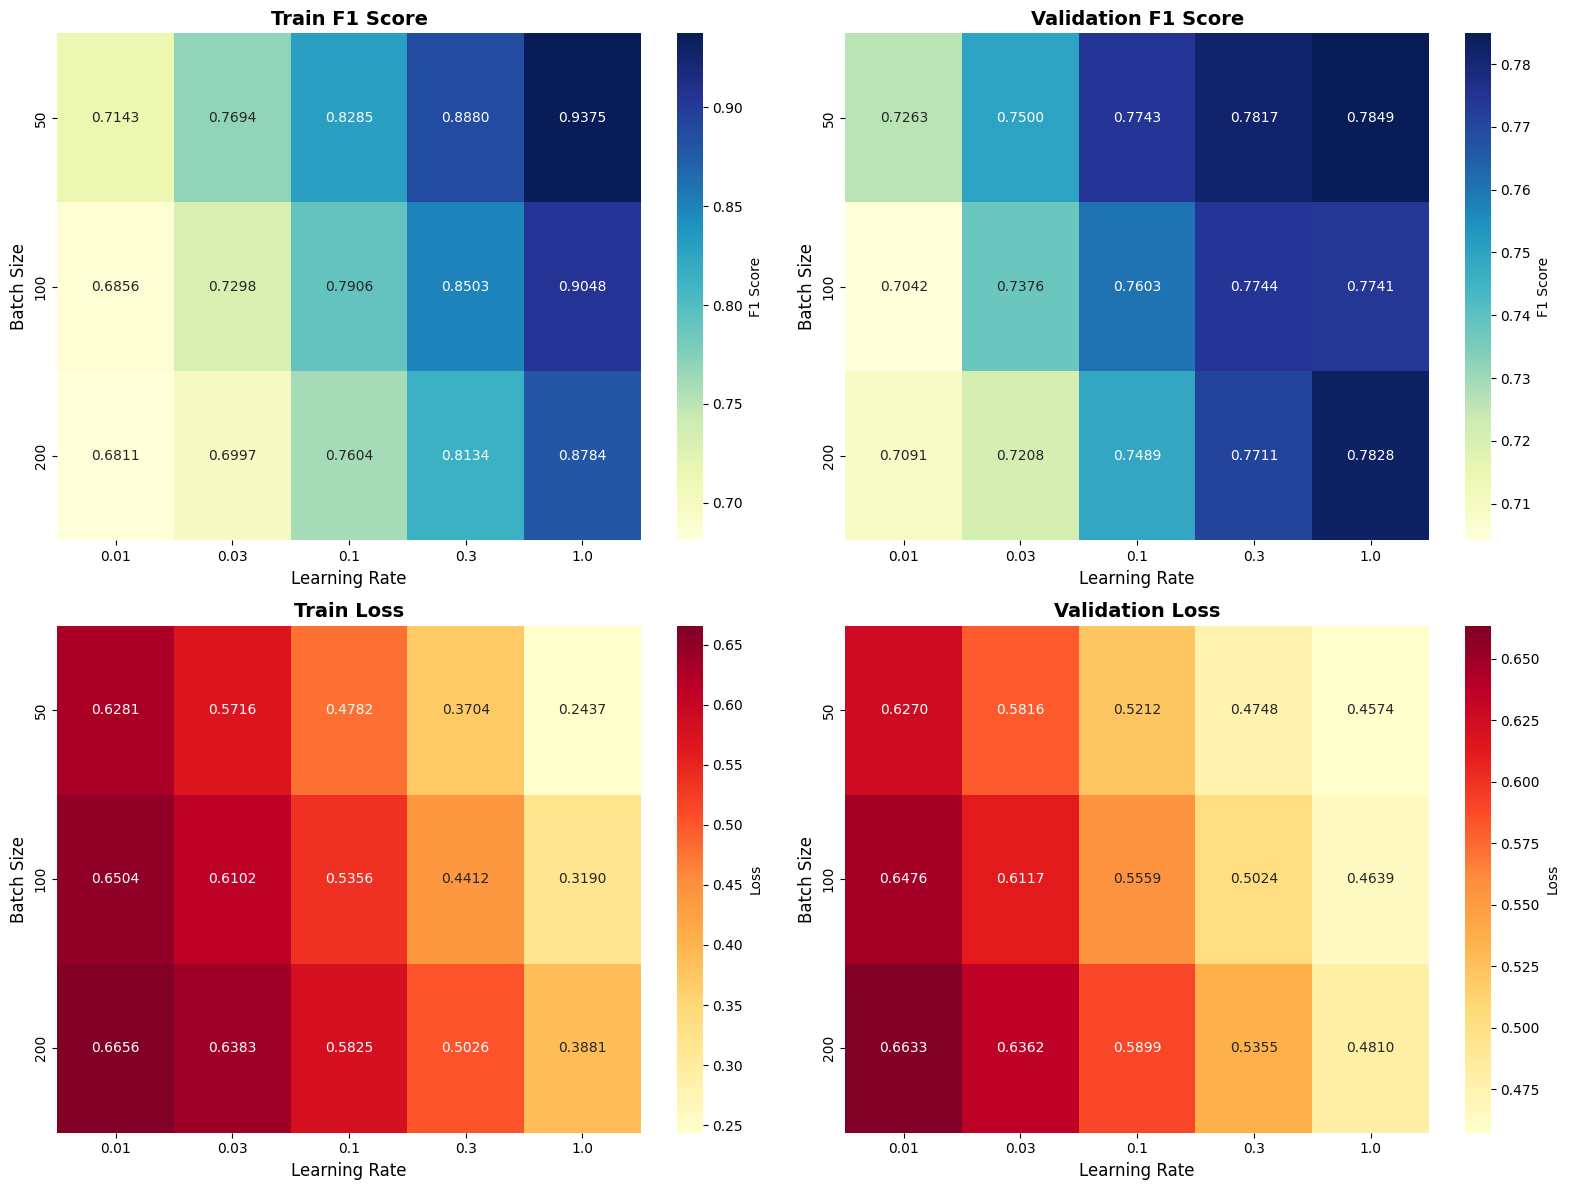


SUMMARY STATISTICS

Best Validation F1 Score: 0.7849
  Achieved with: Batch Size = 50, Learning Rate = 1.0

Lowest Validation Loss: 0.4574
  Achieved with: Batch Size = 50, Learning Rate = 1.0


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define hyperparameter grids
learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

# Storage for results
results = {
    "train_metric": np.zeros((len(batch_sizes), len(learning_rates))),
    "val_metric": np.zeros((len(batch_sizes), len(learning_rates))),
    "train_loss": np.zeros((len(batch_sizes), len(learning_rates))),
    "val_loss": np.zeros((len(batch_sizes), len(learning_rates))),
}
all_logs = {}  # full per-epoch history for each (batch_size, lr)

# Run experiments
print("Running experiments...")
for i, batch_size in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        # Reset seeds for each experiment
        random.seed(42)
        np.random.seed(42)
        torch.manual_seed(42)

        print(f"\nBatch size: {batch_size}, Learning rate: {lr}")

        # Train model
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train,
            y_train,
            X_val,
            y_val,
            lr=lr,
            epochs=20,
            batch_size=batch_size,
            init="zeros",
            metric="f1",
            print_metrics=False,
        )

        # Store final results
        final_epoch = epoch_log[-1]
        results["train_metric"][i, j] = final_epoch["train_metric"]
        results["val_metric"][i, j] = final_epoch["val_metric"]
        results["train_loss"][i, j] = final_epoch["train_loss"]
        results["val_loss"][i, j] = final_epoch["val_loss"]
        all_logs[(batch_size, lr)] = epoch_log

        print(
            f"  Train F1: {final_epoch['train_metric']:.4f}, Val F1: {final_epoch['val_metric']:.4f}"
        )
        print(
            f"  Train Loss: {final_epoch['train_loss']:.4f}, Val Loss: {final_epoch['val_loss']:.4f}"
        )

# Create heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Train Metric Heatmap
sns.heatmap(
    results["train_metric"],
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    xticklabels=learning_rates,
    yticklabels=batch_sizes,
    ax=axes[0, 0],
    cbar_kws={"label": "F1 Score"},
)
axes[0, 0].set_title("Train F1 Score", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Learning Rate", fontsize=12)
axes[0, 0].set_ylabel("Batch Size", fontsize=12)

# Validation Metric Heatmap
sns.heatmap(
    results["val_metric"],
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    xticklabels=learning_rates,
    yticklabels=batch_sizes,
    ax=axes[0, 1],
    cbar_kws={"label": "F1 Score"},
)
axes[0, 1].set_title("Validation F1 Score", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Learning Rate", fontsize=12)
axes[0, 1].set_ylabel("Batch Size", fontsize=12)

# Train Loss Heatmap
sns.heatmap(
    results["train_loss"],
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    xticklabels=learning_rates,
    yticklabels=batch_sizes,
    ax=axes[1, 0],
    cbar_kws={"label": "Loss"},
)
axes[1, 0].set_title("Train Loss", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Learning Rate", fontsize=12)
axes[1, 0].set_ylabel("Batch Size", fontsize=12)

# Validation Loss Heatmap
sns.heatmap(
    results["val_loss"],
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    xticklabels=learning_rates,
    yticklabels=batch_sizes,
    ax=axes[1, 1],
    cbar_kws={"label": "Loss"},
)
axes[1, 1].set_title("Validation Loss", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Learning Rate", fontsize=12)
axes[1, 1].set_ylabel("Batch Size", fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nBest Validation F1 Score: {results['val_metric'].max():.4f}")
best_idx = np.unravel_index(results["val_metric"].argmax(), results["val_metric"].shape)
print(
    f"  Achieved with: Batch Size = {batch_sizes[best_idx[0]]}, Learning Rate = {learning_rates[best_idx[1]]}"
)

print(f"\nLowest Validation Loss: {results['val_loss'].min():.4f}")
best_loss_idx = np.unravel_index(
    results["val_loss"].argmin(), results["val_loss"].shape
)
print(
    f"  Achieved with: Batch Size = {batch_sizes[best_loss_idx[0]]}, Learning Rate = {learning_rates[best_loss_idx[1]]}"
)

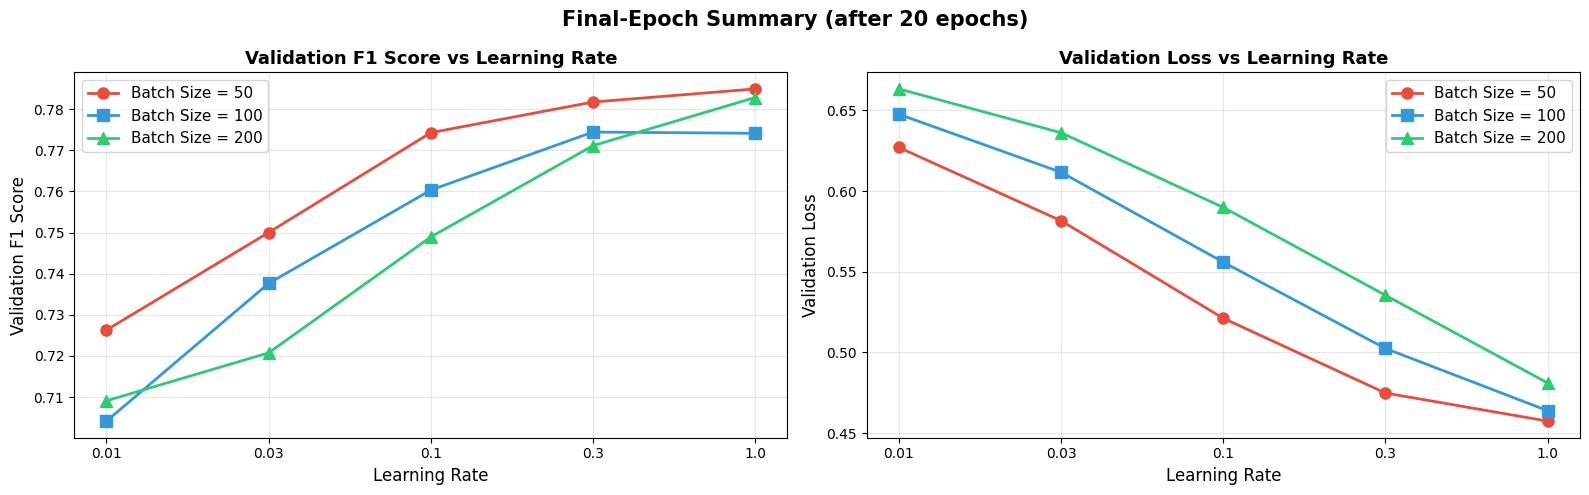

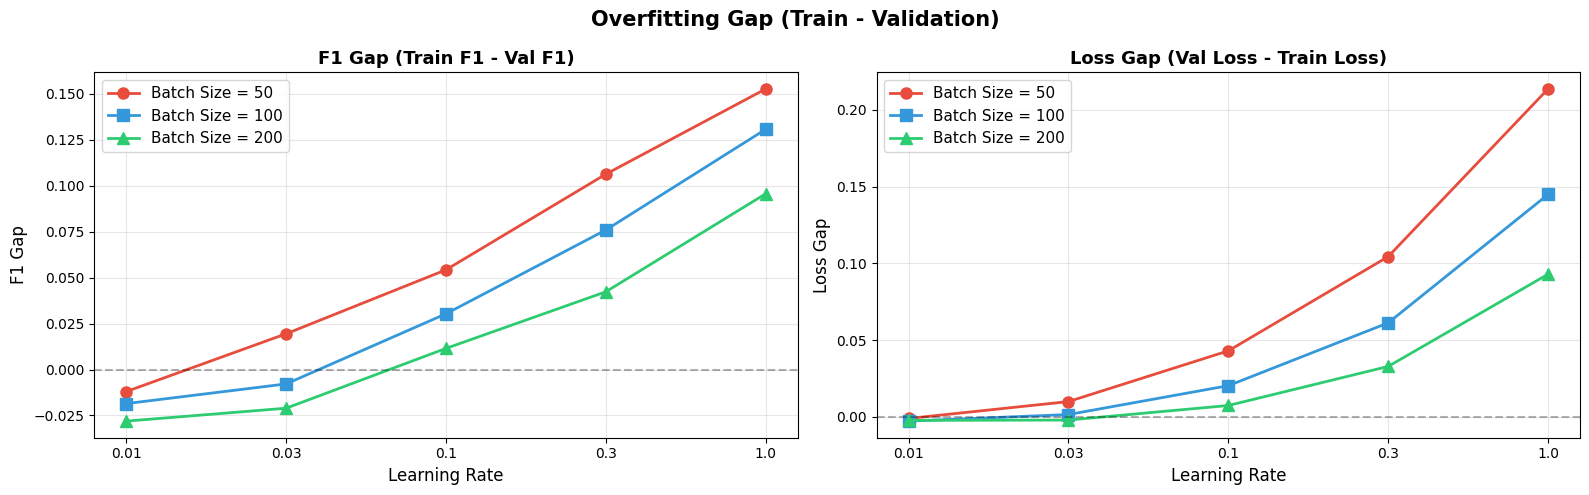

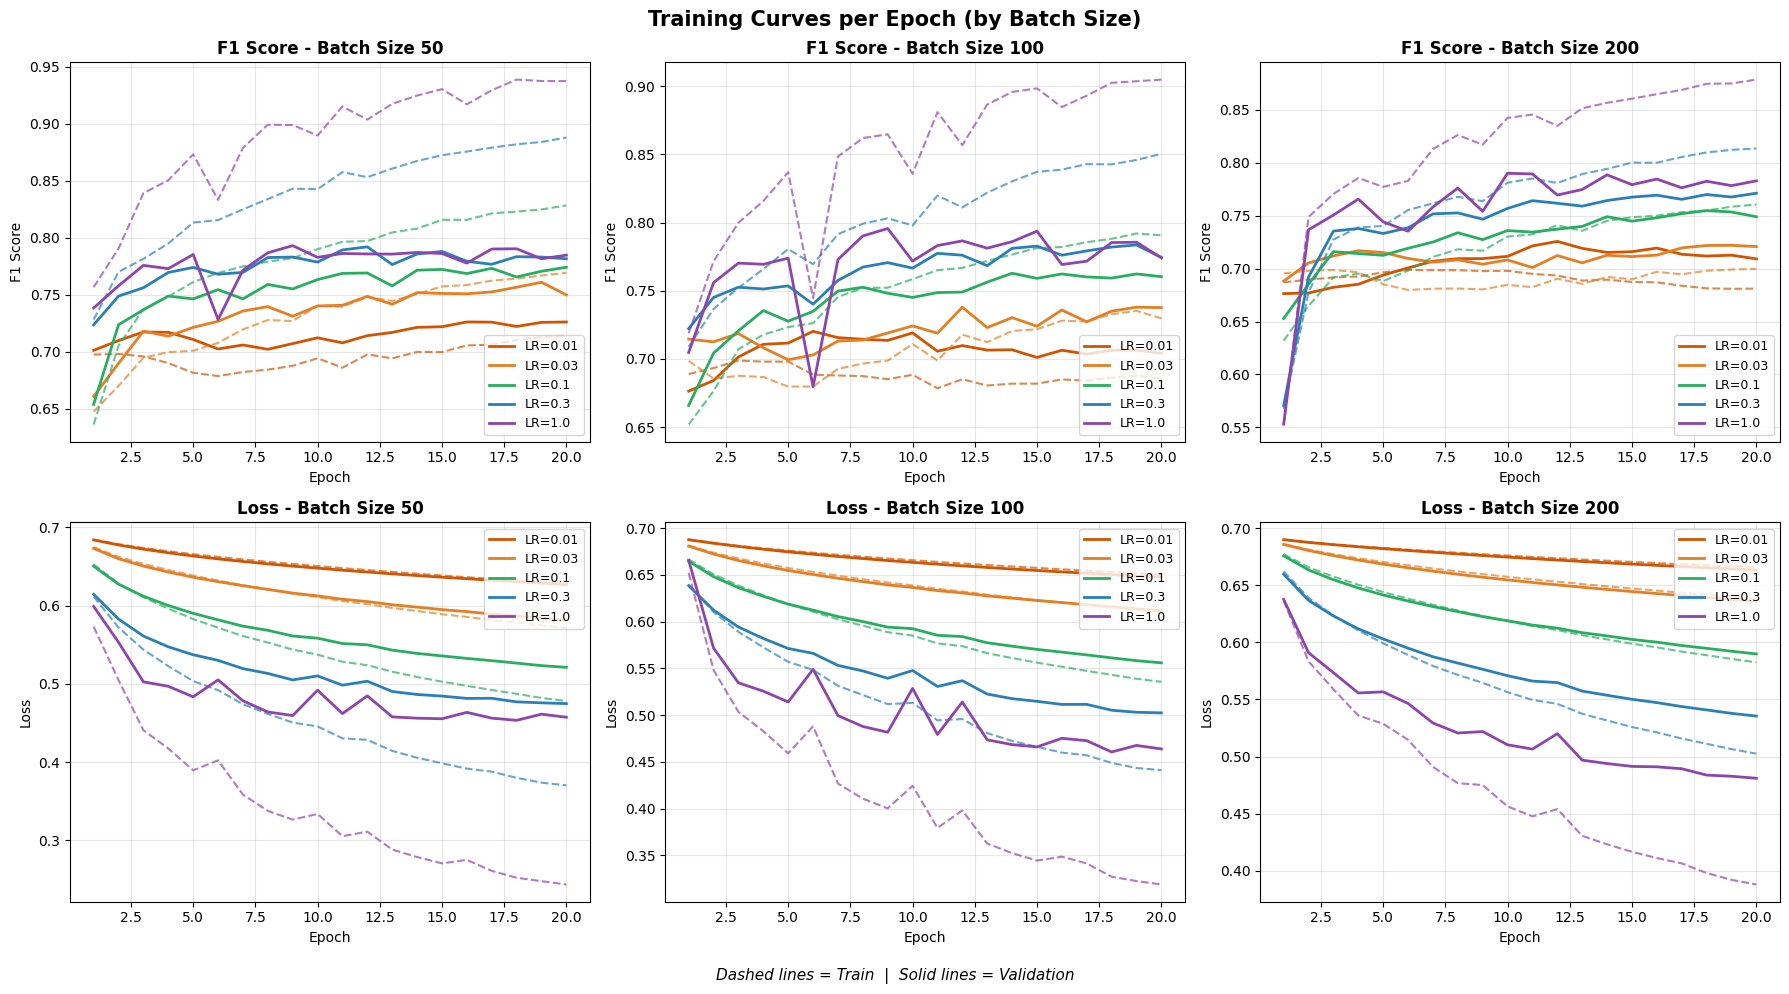

In [13]:
markers = ["o", "s", "^"]
colors_bs = ["#e74c3c", "#3498db", "#2ecc71"]
lr_colors = ["#d35400", "#e67e22", "#27ae60", "#2980b9", "#8e44ad"]
epochs_range = list(range(1, 21))

# ── Section 1: Final-epoch summary (val F1 + val loss vs LR) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Final-Epoch Summary (after 20 epochs)", fontsize=15, fontweight="bold")

for i, batch_size in enumerate(batch_sizes):
    axes[0].plot(
        [str(lr) for lr in learning_rates],
        results["val_metric"][i],
        marker=markers[i],
        color=colors_bs[i],
        linewidth=2,
        markersize=8,
        label=f"Batch Size = {batch_size}",
    )
axes[0].set_title(
    "Validation F1 Score vs Learning Rate", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Learning Rate", fontsize=12)
axes[0].set_ylabel("Validation F1 Score", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

for i, batch_size in enumerate(batch_sizes):
    axes[1].plot(
        [str(lr) for lr in learning_rates],
        results["val_loss"][i],
        marker=markers[i],
        color=colors_bs[i],
        linewidth=2,
        markersize=8,
        label=f"Batch Size = {batch_size}",
    )
axes[1].set_title("Validation Loss vs Learning Rate", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Learning Rate", fontsize=12)
axes[1].set_ylabel("Validation Loss", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Section 2: Overfitting gap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Overfitting Gap (Train - Validation)", fontsize=15, fontweight="bold")

for i, batch_size in enumerate(batch_sizes):
    axes[0].plot(
        [str(lr) for lr in learning_rates],
        results["train_metric"][i] - results["val_metric"][i],
        marker=markers[i],
        color=colors_bs[i],
        linewidth=2,
        markersize=8,
        label=f"Batch Size = {batch_size}",
    )
axes[0].set_title("F1 Gap (Train F1 - Val F1)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Learning Rate", fontsize=12)
axes[0].set_ylabel("F1 Gap", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color="black", linestyle="--", alpha=0.3)

for i, batch_size in enumerate(batch_sizes):
    axes[1].plot(
        [str(lr) for lr in learning_rates],
        results["val_loss"][i] - results["train_loss"][i],
        marker=markers[i],
        color=colors_bs[i],
        linewidth=2,
        markersize=8,
        label=f"Batch Size = {batch_size}",
    )
axes[1].set_title("Loss Gap (Val Loss - Train Loss)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Learning Rate", fontsize=12)
axes[1].set_ylabel("Loss Gap", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ── Section 3: Training curves per epoch (one subplot per batch size) ─────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Training Curves per Epoch (by Batch Size)", fontsize=15, fontweight="bold"
)

for i, batch_size in enumerate(batch_sizes):
    ax_f1 = axes[0, i]
    ax_loss = axes[1, i]

    for j, lr in enumerate(learning_rates):
        log = all_logs[(batch_size, lr)]
        train_f1 = [e["train_metric"] for e in log]
        val_f1 = [e["val_metric"] for e in log]
        train_loss = [e["train_loss"] for e in log]
        val_loss = [e["val_loss"] for e in log]

        ax_f1.plot(
            epochs_range,
            train_f1,
            color=lr_colors[j],
            linewidth=1.5,
            linestyle="--",
            alpha=0.7,
        )
        ax_f1.plot(
            epochs_range, val_f1, color=lr_colors[j], linewidth=2, label=f"LR={lr}"
        )
        ax_loss.plot(
            epochs_range,
            train_loss,
            color=lr_colors[j],
            linewidth=1.5,
            linestyle="--",
            alpha=0.7,
        )
        ax_loss.plot(
            epochs_range, val_loss, color=lr_colors[j], linewidth=2, label=f"LR={lr}"
        )

    ax_f1.set_title(
        f"F1 Score - Batch Size {batch_size}", fontsize=12, fontweight="bold"
    )
    ax_f1.set_xlabel("Epoch", fontsize=10)
    ax_f1.set_ylabel("F1 Score", fontsize=10)
    ax_f1.legend(fontsize=9, loc="lower right")
    ax_f1.grid(True, alpha=0.3)

    ax_loss.set_title(f"Loss - Batch Size {batch_size}", fontsize=12, fontweight="bold")
    ax_loss.set_xlabel("Epoch", fontsize=10)
    ax_loss.set_ylabel("Loss", fontsize=10)
    ax_loss.legend(fontsize=9, loc="upper right")
    ax_loss.grid(True, alpha=0.3)

# Shared legend note: dashed = train, solid = validation
fig.text(
    0.5,
    0.01,
    "Dashed lines = Train  |  Solid lines = Validation",
    ha="center",
    fontsize=11,
    style="italic",
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Analysis: Effect of Learning Rate and Batch Size on Training

### 1. Convergence Speed

**Learning Rate is the dominant factor for convergence speed.**

The per-epoch training curves clearly show this: at LR=0.01 and LR=0.03, both the F1 and loss curves are nearly flat throughout all 20 epochs - the model is still slowly improving at epoch 20 and has not converged. In contrast, LR=0.3 and LR=1.0 converge visibly within the first 5–10 epochs, after which the curves plateau.

- **LR=0.01 / 0.03**: Underfitting regime - not enough progress in 20 epochs. Val F1 peaks at 0.726 and 0.721 respectively (batch=200). Training is still descending at the last epoch.
- **LR=0.1**: Converges by ~epoch 15. Reasonable performance across all batch sizes (val F1 ≈ 0.75–0.77).
- **LR=0.3 / 1.0**: Fast convergence within the first 5–8 epochs. LR=1.0 achieves the best final validation F1 (0.7849) and lowest validation loss (0.4574), both with batch size=50.

**Batch size affects convergence speed secondarily.** Smaller batches (50) make more gradient updates per epoch, so they converge faster - at LR=0.01, batch=50 reaches val F1=0.726 while batch=100 only reaches 0.704. However, this advantage shrinks as LR increases: at LR=1.0, all batch sizes converge to a similar final val F1 (~0.77–0.78).

---

### 2. Stability of Training

**High LR + small batch = fast but noisy.** The training curves for LR=1.0 (purple lines) show visible oscillations in both F1 and loss, especially for batch sizes 50 and 100. This is because small batches produce high-variance gradient estimates, and a large step size amplifies those fluctuations.

- **LR=1.0, batch=50**: The loss curve oscillates noticeably in the first 10 epochs before settling. The train F1 dashed curve is unstable early on.
- **LR=1.0, batch=200**: Smoother curves - larger batches produce more stable gradient estimates, reducing the oscillations even at aggressive learning rates.
- **LR=0.01–0.1**: All batch sizes show smooth, monotonically improving curves - stability is not a concern here, though the trade-off is very slow progress.

The overfitting gap plot (Val Loss − Train Loss) confirms that instability compounds with overfitting: at LR=1.0, batch=50 accumulates a loss gap of ~0.21 by epoch 20, while batch=200 at the same LR stays below ~0.10.

---

### 3. Final Performance

**Best overall configuration: batch=50, LR=1.0** - achieves val F1=**0.7849** and val loss=**0.4574**, the best of all 15 experiments.

However, the overfitting gap plots reveal an important nuance:

- **Low LR (0.01–0.03)**: The train-val F1 gap is near **zero or even negative** (val > train). This indicates underfitting - the model hasn't learned enough from the training data, and both sets perform similarly poorly.
- **High LR (0.3–1.0)**: The gap grows significantly. At LR=1.0, batch=50, the train F1 reaches 0.9375 while val F1 is only 0.7849 - a gap of **0.15**. The model is memorizing training patterns that don't generalize.
- **Most stable generalization: batch=200, LR=1.0** - val F1=0.7828, loss gap only ~0.10, almost as good as the best but with much less overfitting.

The heatmaps confirm this: the Train F1 heatmap shows a steep diagonal gradient (top-right is dark), while the Validation F1 heatmap is much flatter - performance gains in training don't translate proportionally to validation.

**All configurations plateau around val F1 ≈ 0.78–0.79.** This ceiling is not a hyperparameter issue - it reflects the inherent limitation of logistic regression on bag-of-words features for sentiment classification.

---

### Key Takeaways

1. **Learning rate is the dominant hyperparameter**: it controls both convergence speed and final performance far more than batch size. Increasing LR from 0.01 to 1.0 improves val F1 by ~0.06–0.07 across all batch sizes.
2. **Low LR is the bigger problem here**: underfitting at LR=0.01 hurts more than overfitting at LR=1.0. Within 20 epochs, the low-LR configs never converge.
3. **Batch size trades off speed vs. stability**: smaller batches converge faster but oscillate more and overfit more at high LR; larger batches are smoother but slower.
4. **Best raw performance**: batch=50, LR=1.0. **Best balance of performance and generalization**: batch=200, LR=1.0.
5. **The ~0.79 val F1 ceiling** is a model-capacity limit, not a hyperparameter problem - a non-linear model with better features would surpass it.

#### **Task 1.5 - L1 Regularization and Sparsity (20 points)**

In this task, you will extend your implementation from Task 1.2 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [ ]:
import random

import numpy as np
import torch

SPARSITY_TOL = 1e-3
LR = 0.1
BATCH_SIZE = 100
EPOCHS = 20
METRIC = "f1"

for penalty, reg_lambda in [("none", 0.0), ("l1", 1e-3)]:
    print(f"\n{'=' * 55}")
    print(f"penalty='{penalty}', reg_lambda={reg_lambda}")
    print(f"{'=' * 55}")

    for init in ["zeros", "random"]:
        random.seed(42)
        np.random.seed(42)
        torch.manual_seed(42)
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train,
            y_train,
            X_val,
            y_val,
            lr=LR,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            init=init,
            penalty=penalty,
            reg_lambda=reg_lambda,
            metric=METRIC,
        )
        final = epoch_log[-1]
        has_nan = bool(np.isnan(w).any() or np.isnan(b).any())
        has_inf = bool(np.isinf(w).any() or np.isinf(b).any())
        loss_grew = epoch_log[-1]["train_loss"] > epoch_log[0]["train_loss"]

        print(f"\n  Init = '{init}'")
        print(
            f"    Stability  - NaN: {has_nan} | Inf: {has_inf} | Loss grew epoch 1→20: {loss_grew}"
        )
        print(
            f"                 Loss epoch 1: {epoch_log[0]['train_loss']:.4f} → epoch 20: {epoch_log[-1]['train_loss']:.4f}"
        )
        print(
            f"    Performance - Train F1: {final['train_metric']:.4f} | Val F1: {final['val_metric']:.4f}"
        )
        print(
            f"    Sparsity   - Near-zero weights (|w| < {SPARSITY_TOL}): {int((np.abs(w) < SPARSITY_TOL).sum())} / {len(w.flatten())}"
        )


penalty='none', reg_lambda=0.0

  Init = 'zeros'
    Stability  - NaN: False | Inf: False | Loss grew epoch 1→20: False
                 Loss epoch 1: 0.6666 → epoch 20: 0.5356
    Performance - Train F1: 0.7906 | Val F1: 0.7603
    Sparsity   - Near-zero weights (|w| < 0.001): 303 / 10000

  Init = 'random'
    Stability  - NaN: False | Inf: False | Loss grew epoch 1→20: False
                 Loss epoch 1: 0.6665 → epoch 20: 0.5356
    Performance - Train F1: 0.7887 | Val F1: 0.7539
    Sparsity   - Near-zero weights (|w| < 0.001): 354 / 10000

penalty='l1', reg_lambda=0.001

  Init = 'zeros'
    Stability  - NaN: False | Inf: False | Loss grew epoch 1→20: False
                 Loss epoch 1: 0.6730 → epoch 20: 0.6102
    Performance - Train F1: 0.7081 | Val F1: 0.7289
    Sparsity   - Near-zero weights (|w| < 0.001): 9438 / 10000

  Init = 'random'
    Stability  - NaN: False | Inf: False | Loss grew epoch 1→20: False
                 Loss epoch 1: 0.6705 → epoch 20: 0.6095
    Per

λ sweep (lr=0.1, batch=100, epochs=20, init='zeros')
-------------------------------------------------------
λ=0e+00  |  Train F1: 0.7906  Val F1: 0.7603  |  Non-zero weights: 9697/10000
λ=1e-04  |  Train F1: 0.7707  Val F1: 0.7497  |  Non-zero weights: 4625/10000
λ=1e-03  |  Train F1: 0.7081  Val F1: 0.7289  |  Non-zero weights: 562/10000
λ=1e-02  |  Train F1: 0.5645  Val F1: 0.5949  |  Non-zero weights: 243/10000
λ=1e-01  |  Train F1: 0.6685  Val F1: 0.6456  |  Non-zero weights: 7534/10000


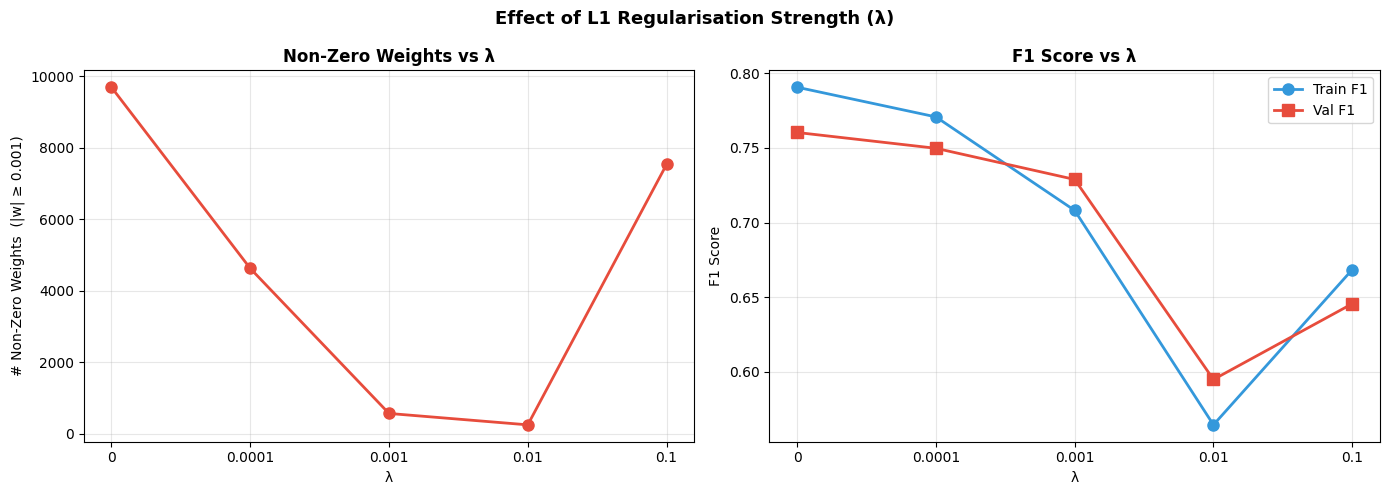

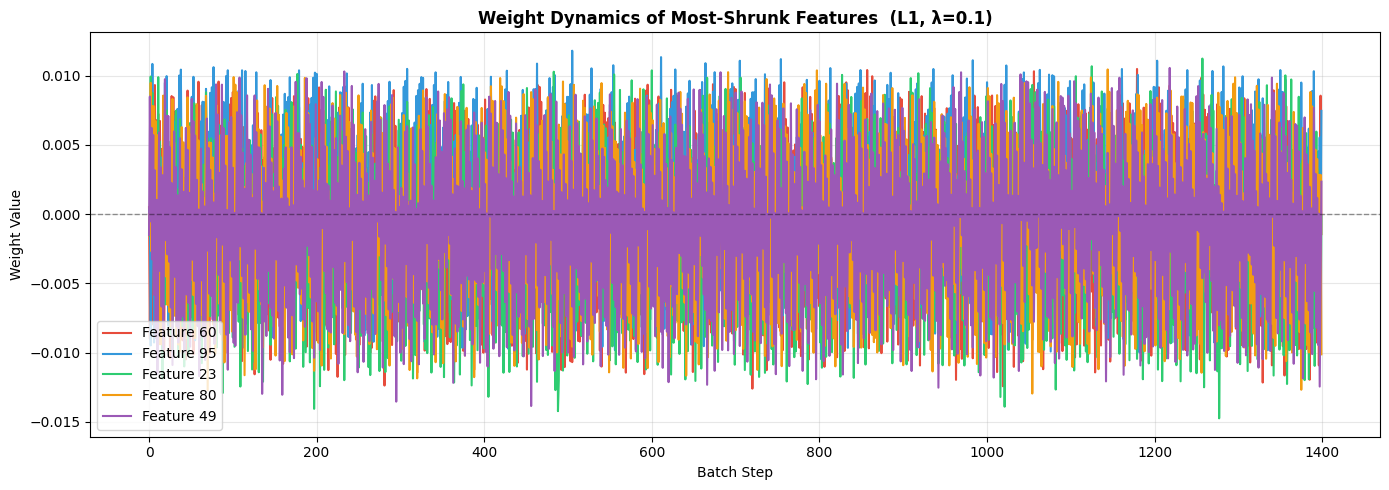

In [15]:
import matplotlib.pyplot as plt

INIT = "zeros"
REG_LAMBDAS = [0, 1e-4, 1e-3, 1e-2, 1e-1]

# ── Part 3: λ sweep ───────────────────────────────────────────────────────────
print("λ sweep (lr=0.1, batch=100, epochs=20, init='zeros')")
print("-" * 55)

lambda_results = {}

for lam in REG_LAMBDAS:
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train,
        y_train,
        X_val,
        y_val,
        lr=LR,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        init=INIT,
        penalty="l1",
        reg_lambda=lam,
        metric=METRIC,
    )
    final = epoch_log[-1]
    nonzero = int((np.abs(w) >= SPARSITY_TOL).sum())
    lambda_results[lam] = dict(
        train_f1=final["train_metric"],
        val_f1=final["val_metric"],
        nonzero=nonzero,
        w=w,
        history=history,
    )
    print(
        f"λ={lam:.0e}  |  Train F1: {final['train_metric']:.4f}  Val F1: {final['val_metric']:.4f}  |  Non-zero weights: {nonzero}/10000"
    )

# ── Part 4a: non-zero weights vs λ ───────────────────────────────────────────
lam_labels = [str(l) for l in REG_LAMBDAS]
nonzeros = [lambda_results[l]["nonzero"] for l in REG_LAMBDAS]
train_f1s = [lambda_results[l]["train_f1"] for l in REG_LAMBDAS]
val_f1s = [lambda_results[l]["val_f1"] for l in REG_LAMBDAS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of L1 Regularisation Strength (λ)", fontsize=13, fontweight="bold")

axes[0].plot(
    lam_labels, nonzeros, marker="o", color="#e74c3c", linewidth=2, markersize=8
)
axes[0].set_title("Non-Zero Weights vs λ", fontsize=12, fontweight="bold")
axes[0].set_xlabel("λ")
axes[0].set_ylabel(f"# Non-Zero Weights  (|w| ≥ {SPARSITY_TOL})")
axes[0].grid(True, alpha=0.3)

# ── Part 4b: train metric vs λ ────────────────────────────────────────────────
axes[1].plot(
    lam_labels,
    train_f1s,
    marker="o",
    color="#3498db",
    linewidth=2,
    markersize=8,
    label="Train F1",
)
axes[1].plot(
    lam_labels,
    val_f1s,
    marker="s",
    color="#e74c3c",
    linewidth=2,
    markersize=8,
    label="Val F1",
)
axes[1].set_title("F1 Score vs λ", fontsize=12, fontweight="bold")
axes[1].set_xlabel("λ")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Part 4c: weight dynamics of near-eliminated features ─────────────────────
# Features with large weight at λ=0 but smallest weight at the highest λ
w_no_reg = lambda_results[0]["w"].flatten()
w_high_reg = lambda_results[REG_LAMBDAS[-1]]["w"].flatten()

# Pick 5 features most shrunk by L1
shrinkage = np.abs(w_no_reg) - np.abs(w_high_reg)
selected_idx = np.argsort(shrinkage)[-5:]

# Re-run highest λ to capture batch-level weight history
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
_, _, history_elim, _ = sgd_logistic_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    lr=0.1,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty="l1",
    reg_lambda=REG_LAMBDAS[-1],
    metric="f1",
)

steps = list(range(len(history_elim)))
colors_dyn = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

fig, ax = plt.subplots(figsize=(14, 5))
for k, feat_idx in enumerate(selected_idx):
    w_traj = [h["w"].flatten()[feat_idx].item() for h in history_elim]
    ax.plot(
        steps, w_traj, color=colors_dyn[k], linewidth=1.5, label=f"Feature {feat_idx}"
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_title(
    f"Weight Dynamics of Most-Shrunk Features  (L1, λ={REG_LAMBDAS[-1]})",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Batch Step")
ax.set_ylabel("Weight Value")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary: Insights on L1 Regularisation

**Weight initialisation (zeros vs random):**
Both initialisations are fully stable (no NaN, no Inf, loss strictly decreasing) and converge to nearly identical results. Without L1, both leave ~303-354 / 10,000 weights near zero - features the data gradient never activates. With L1 (λ=1e-3), both push 94% of weights below 0.001, keeping only ~560 active features. The 0.001 difference in Val F1 between the two initialisations is negligible. This is expected: logistic regression is a convex problem with a single global minimum, so initialisation affects the path taken, not the destination.

**Effect of λ on sparsity:**
Using a threshold of 1e-3 (appropriate for SGD-trained weights), sparsity increases sharply with λ in the range 0 → 1e-2:
- λ=0: 9,697 active weights (97% of features)
- λ=1e-4: 4,625 active weights (46%)
- λ=1e-3: 562 active weights (5.6%)
- λ=1e-2: 243 active weights (2.4%)

This confirms L1's role as an implicit feature selector - it identifies and suppresses uninformative features while preserving the most predictive ones.

**Effect of λ on performance:**
There is a clear performance–sparsity trade-off in the range λ=0 to λ=1e-2: Val F1 drops from 0.7603 → 0.7497 → 0.7289 → 0.5949. Notably, the model retains 0.7289 Val F1 using only 562 features (vs 9,697 without regularisation) - a drop of just 0.031 F1 for a 94% reduction in active features. λ=1e-3 is the best trade-off point.

**Anomaly at λ=0.1 - SGD breakdown:**
At λ=0.1, both Val F1 (0.6456) and the non-zero weight count (7,534) unexpectedly increase relative to λ=1e-2. This is not a recovery - it is a sign of optimisation instability. With lr=0.1 and λ=0.1, the L1 gradient (`λ × sign(w) = 0.1`) is equal in magnitude to the learning rate, causing weights to oscillate continuously between positive and negative values without converging. The weight dynamics plot confirms this: all 5 tracked features show chaotic, non-convergent oscillation throughout all 1,400 batch steps. This is a known limitation of applying L1 via SGD - proximal gradient descent would handle this correctly by applying a soft-threshold operator that produces true zeros analytically.

---
### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (30 points)**

In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A - Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B - the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [16]:
import matplotlib.pyplot as plt
import torch


# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2 * y**2


# camel
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2 + x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(
    f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"
):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(
            trajectory[:, 0], trajectory[:, 1], marker="o", markersize=2, label=name
        )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        # TODO: compute loss
        loss = ...

        # TODO: compute gradients
        ...

        # TODO: update parameters
        with torch.no_grad():
            theta -= ...

        # reset gradients
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update velocity
            v = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: accumulate squared gradients
            G = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update moments
            m = ...
            v = ...

            # TODO: bias correction
            m_hat = ...
            v_hat = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values


# Run experiments

theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=...),
    "Momentum": momentum(bowl, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(bowl, theta0, lr=...),
    "Adam": adam(bowl, theta0, lr=...),
}

results_camel = {
    "GD": gradient_descent(camel, theta0, lr=...),
    "Momentum": momentum(camel, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(camel, theta0, lr=...),
    "Adam": adam(camel, theta0, lr=...),
}

/var/folders/4p/3v7c85y55qdc7jt3wv838n700000gp/T/ipykernel_29196/2621722839.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)


TypeError: unsupported operand type(s) for -=: 'Tensor' and 'ellipsis'

### **Knowledge Bonus.** An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent



The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$